<center> <h1> Credit Card Fraud Detection Project </h1> </center>

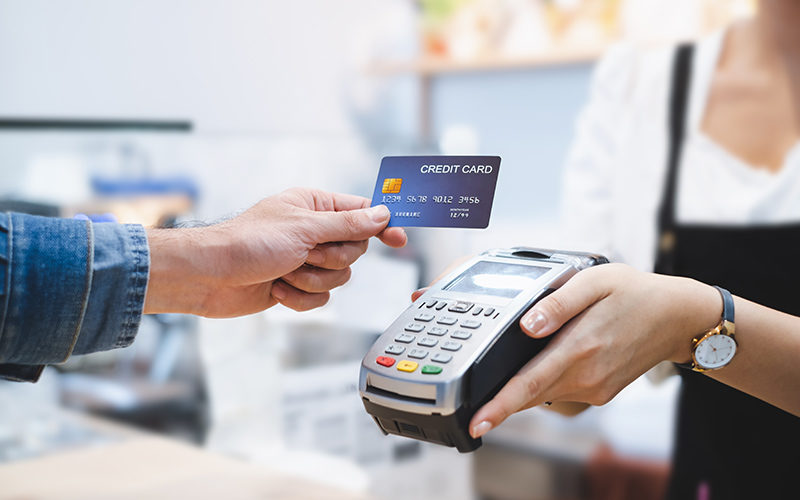

In [42]:
from IPython.display import Image, display
display(Image(filename="header_image.png"))

In [43]:
#Import the required libraries:
import numpy as np
import pandas as pd


#for simple pipeline: from sklearn.pipeline import Pipeline
#for SMOTE use this pipeline:
from imblearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report , confusion_matrix


import seaborn as sns
import matplotlib.pyplot as plt

#For ignoring all the incoming warnings (if any):
import warnings
warnings.filterwarnings("ignore")



In [44]:
#Load the dataset:
df = pd.read_csv("creditcard.csv/creditcard.csv")

#Preview the data using first 5 rows:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [45]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [46]:
#Dataset information:
df.info()

print("\n\n")

df.isnull().sum()

print("\n\n")

df.duplicated().sum

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

<bound method Series.sum of 0         False
1         False
2         False
3         False
4         False
          ...  
284802    False
284803    False
284804    False
284805    False
284806    False
Length: 284807, dtype: bool>

In [47]:
#Distributions of valid transactions and fraud transactions:
df["Class"].value_counts().reset_index(name="Frequency")

,Class,Frequency
0,0,284315
1,1,492


### Conclusion at this point: This dataset is highly imbalanced. Hence we will first seperate out both these types of transactions

In [48]:
legit = df[df["Class"]==0]
fraud = df[df["Class"]==1]

print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


In [49]:
#Statistical summary of both the types of transactions:

print("For legit transactions:")
legit["Amount"].describe()




For legit transactions:


count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [50]:
print("For fraud transactions:")
fraud["Amount"].describe()


For fraud transactions:


count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [51]:
new_dataset = df.copy()

# Check first 5 rows
new_dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [52]:
#Check the last 5 rows of the new merged datatset:
new_dataset.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


#### Machine-Learning part:


In [53]:
X = new_dataset.drop(columns="Class",axis=1)
Y = new_dataset["Class"]



In [54]:
X_train, X_test,y_train , y_test = train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=2)

#For handling the imbalanced data (for handling the imbalanced data which we saw earlier):
from imblearn.over_sampling import SMOTE

model_1 = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])
model_2 = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", GaussianNB())
])

model_3 = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])



model_1.fit(X_train,y_train)
model_2.fit(X_train,y_train)
model_3.fit(X_train, y_train)

y_pred_1 = model_1.predict(X_test)
y_pred_2 = model_2.predict(X_test)
y_pred_rf = model_3.predict(X_test)


print("Accuracy for Logistic Regression:", accuracy_score(y_test, y_pred_1))
print(classification_report(y_test, y_pred_1))

print("\n\n")

print("Accuracy for Naive Bayes:", accuracy_score(y_test, y_pred_2))
print(classification_report(y_test, y_pred_2))

print("\n\n")

print("Accuracy for Random Forest:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy for Logistic Regression: 0.9737017660896738
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.95      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.96      0.55     56962
weighted avg       1.00      0.97      0.99     56962




Accuracy for Naive Bayes: 0.9764404339735262
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.90      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.98      0.99     56962




Accuracy for Random Forest: 0.9985428882412837
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.55      0.90      0.68        98

    accuracy                   

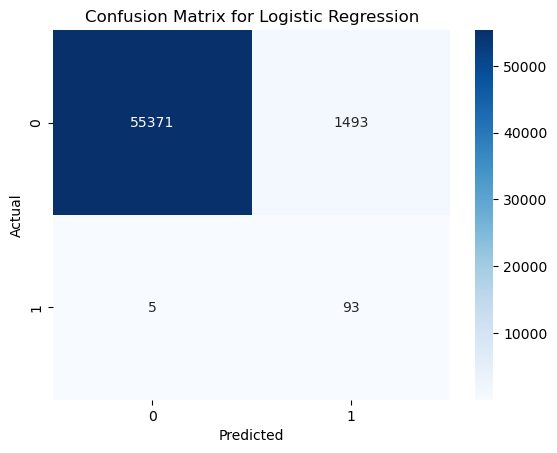

In [55]:


cm = confusion_matrix(y_test, y_pred_1)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Logistic Regression")

plt.show()

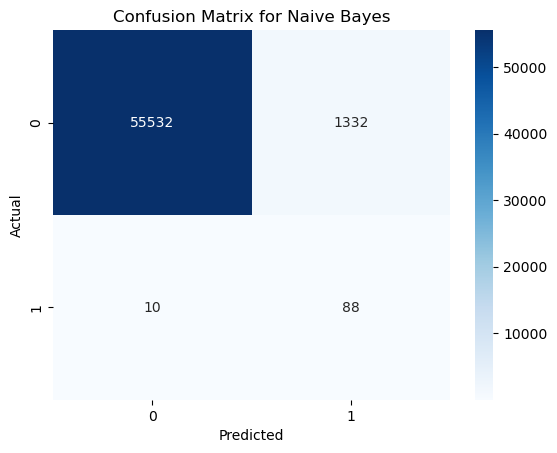

In [56]:


cm = confusion_matrix(y_test, y_pred_2)


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Naive Bayes")

plt.show()

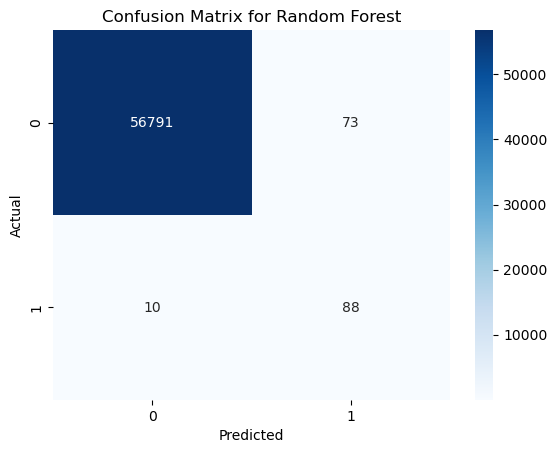

In [57]:

cm = confusion_matrix(y_test, y_pred_rf)


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Random Forest")

plt.show()

In [58]:

# Logistic Regression predictions
lra_train = model_1.predict(X_train)
lra_test = model_1.predict(X_test)

# Naive Bayes predictions
nba_train = model_2.predict(X_train)
nba_test = model_2.predict(X_test)

# Random Forest predictions
rf_train = model_3.predict(X_train)
rf_test = model_3.predict(X_test)


# Accuracy calculation
print("Logistic Train Accuracy:", accuracy_score(y_train, lra_train))
print("Logistic Test Accuracy:", accuracy_score(y_test, lra_test))

print("Naive Bayes Train Accuracy:", accuracy_score(y_train, nba_train))
print("Naive Bayes Test Accuracy:", accuracy_score(y_test, nba_test))

print("Random Forest Train Accuracy:", accuracy_score(y_train, rf_train))
print("Random Forest Test Accuracy:", accuracy_score(y_test, rf_test))




Logistic Train Accuracy: 0.9740569246636969
Logistic Test Accuracy: 0.9737017660896738
Naive Bayes Train Accuracy: 0.9763523447958041
Naive Bayes Test Accuracy: 0.9764404339735262
Random Forest Train Accuracy: 0.9990256534047269
Random Forest Test Accuracy: 0.9985428882412837


      Metric  Logistic Regression  Naive Bayes  Random Forest
0   Accuracy             0.974776     0.975928       0.998680
1  Precision             0.059315     0.058796       0.582468
2     Recall             0.912533     0.859761       0.847578
3   F1-Score             0.111367     0.110047       0.690055


<Figure size 2000x800 with 0 Axes>

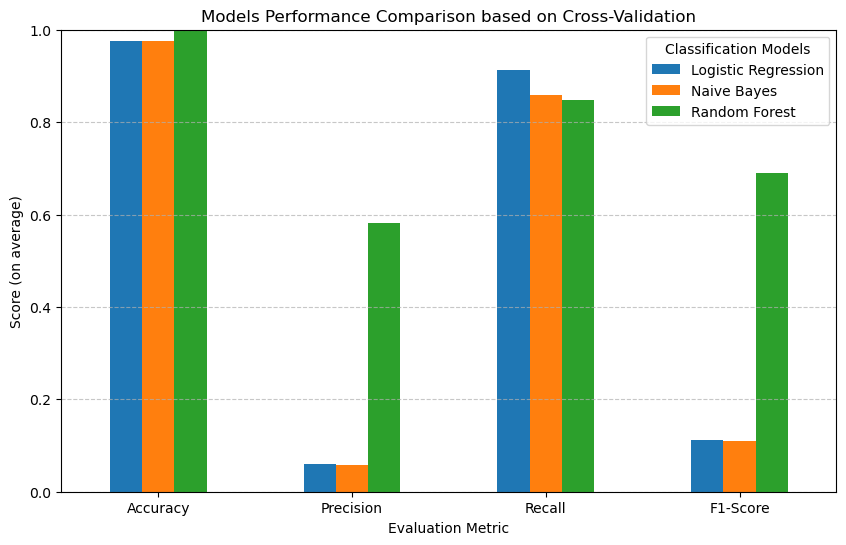

In [59]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd
import matplotlib.pyplot as plt

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics to evaluate
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Cross-validation for Logistic Regression
log_cv = cross_validate(model_1, X, Y, cv=cv, scoring=scoring)

# Cross-validation for Naive Bayes
nb_cv = cross_validate(model_2, X, Y, cv=cv, scoring=scoring)

# Cross-validation for Random Forest
rf_cv = cross_validate(model_3, X, Y, cv=cv, scoring=scoring)


# Store mean scores
results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression': [
        log_cv['test_accuracy'].mean(),
        log_cv['test_precision'].mean(),
        log_cv['test_recall'].mean(),
        log_cv['test_f1'].mean()
    ],
    'Naive Bayes': [
        nb_cv['test_accuracy'].mean(),
        nb_cv['test_precision'].mean(),
        nb_cv['test_recall'].mean(),
        nb_cv['test_f1'].mean()
    ],
    'Random Forest': [
        rf_cv['test_accuracy'].mean(),
        rf_cv['test_precision'].mean(),
        rf_cv['test_recall'].mean(),
        rf_cv['test_f1'].mean()
    ]
})

# Print results
print(results)

plt.figure(figsize=(20,8))
# Plot graph
results.set_index('Metric').plot(kind='bar', figsize=(10, 6))
plt.title('Models Performance Comparison based on Cross-Validation')
plt.ylabel('Score (on average)')
plt.xlabel('Evaluation Metric')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Classification Models')
plt.show()

#### **NOTE:** No need to use Hyper-parameter tuning on the Random-Forest model; since it already has high accuracy.

In [60]:
#Since the Random Forest model shows the highest accuracy ; we will export it (on our local machine):
import joblib
joblib.dump(model_3, "Final_Credit_Card_Fraud_Detection.pkl")

['Final_Credit_Card_Fraud_Detection.pkl']

# Credit Card Fraud Detection using Logistic Regression , Naive Bayes And Random Forest

This project focuses on detecting fraudulent credit card transactions using machine learning classification models. The main objective is to classify a transaction as either **fraudulent** or **non-fraudulent** based on the given transaction features.

Three machine learning models were used in this project:

- **Logistic Regression**
- **Naive Bayes**
- **Random Forest**

The models were trained, tested, evaluated, compared using cross-validation, and finally the Random Forest model was exported for future use.





## Problem Statement

Credit card fraud is one of the major issues in the banking and financial sector. Fraudulent transactions are very rare compared to normal transactions, which makes this a highly imbalanced classification problem.

The goal of this project is to build classification models that can predict whether a transaction is:

- **0 = Normal Transaction**
- **1 = Fraudulent Transaction**

This helps financial institutions identify suspicious activity and reduce losses.





    
## About the Dataset

The dataset used in this project is the **Credit Card Fraud Detection dataset**.

### Dataset characteristics:
- Each **row** represents one credit card transaction.
- Each **column** represents one feature describing that transaction.
- The **Class** column is the target variable.

### Important columns:
- **Time**: Time elapsed between this transaction and the first transaction in the dataset
- **Amount**: Transaction amount
- **V1 to V28**: Anonymized numerical features obtained after PCA transformation
- **Class**:
  - `0` → Normal transaction
  - `1` → Fraud transaction

### Important note:
This dataset is **highly imbalanced**, because fraudulent transactions are much fewer than genuine transactions.




## Project Workflow

The project was completed in the following steps:

1. Importing required libraries
2. Loading the dataset
3. Understanding the data
4. Checking class distribution
5. Separating features and target
6. Splitting the data into training and testing sets
7. Training Logistic Regression model
8. Training Naive Bayes model
9. Training Random Forest model
10. Evaluating all models on training and testing data
11. Performing cross-validation
12. Plotting graph for model performance comparison
13. Exporting the final Random Forest model







## Loading the Dataset

The dataset was loaded into a pandas DataFrame for analysis and model training.

After loading the data, the initial rows were inspected to understand the structure of the dataset.






## Understanding the Dataset

The dataset contains transaction-related information in numerical format.

### What rows represent:
Each row corresponds to a single transaction.

### What columns represent:
Each column represents one feature or property of that transaction.

For example:
- `Amount` shows the transaction amount
- `Time` shows the transaction timing
- `V1` to `V28` are transformed numerical features
- `Class` tells whether the transaction is fraud or not





## Class Distribution

Before training the models, the distribution of the target variable was checked.

This is important because the dataset is **imbalanced**:
- Most transactions belong to Class `0` (normal)
- Very few transactions belong to Class `1` (fraud)

Because of this imbalance, relying only on **accuracy** can be misleading. Therefore, other performance metrics such as **precision**, **recall**, and **F1-score** are also important.




## Feature and Target Separation

The dataset was divided into:

- **X** → input features
- **y** → target variable (`Class`)

This is required so that the machine learning models can learn from the input features and predict the target class.



## Splitting the Data into Training and Testing Sets

The data was split into two parts:

- **Training data** → used to train the model
- **Testing data** → used to evaluate the model

This helps measure how well the model performs on unseen data.



## Logistic Regression Model

Logistic Regression is a supervised machine learning classification algorithm used for binary classification problems.

In this project, Logistic Regression was used to predict whether a transaction is fraudulent or not.

### Why Logistic Regression?
- Simple and effective baseline model
- Works well for binary classification
- Fast to train
- Easy to interpret





## Naive Bayes Model

Naive Bayes is a probabilistic classification algorithm based on Bayes' Theorem.

It assumes that all features are independent from each other, which is why it is called **naive**.

### Why Naive Bayes?
- Fast and simple
- Works well on many classification problems
- Good for comparing with Logistic Regression



## Random Forest Model

Random Forest is a supervised machine learning algorithm that uses multiple decision trees to perform classification.

It builds many decision trees and combines their predictions to produce a more accurate and stable result.

In this project, Random Forest was used to predict whether a transaction is fraudulent or not.

### Why Random Forest
- Handles complex and non-linear relationships in data
- Works well with imbalanced datasets (especially with class_weight)
- Reduces overfitting compared to a single decision tree
- Provides high accuracy in many real-world problems
- Does not require heavy data preprocessing




## Model Training

Both models were trained using the training dataset:

- Logistic Regression was fitted on the training data
- Naive Bayes was also fitted on the training data

After training, predictions were made on both:
- training data
- testing data



## Model Evaluation

The performance of both models was evaluated using:

- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**

### Why multiple metrics were used:
Since the dataset is imbalanced, accuracy alone is not enough.

For fraud detection:
- **Precision** tells how many predicted frauds were actually frauds
- **Recall** tells how many actual frauds were correctly detected
- **F1-score** gives a balance between precision and recall



## Accuracy on Training and Testing Data

Predictions were made using both models on training and testing data.

Then, `accuracy_score()` was used to calculate the accuracy.




## Cross-Validation

To evaluate the models more reliably, **cross-validation** was performed.

### What cross-validation does:
Instead of checking performance on just one train-test split, cross-validation divides the data into multiple folds and tests the model multiple times.

In this project:
- **Stratified K-Fold Cross-Validation** was used
- This ensures that the class distribution is preserved in each fold

### Benefits:
- More reliable evaluation
- Reduces dependence on one random train-test split
- Better comparison between models


## Cross-Validation Metrics Used

The following metrics were used during cross-validation:

- Accuracy
- Precision
- Recall
- F1-score

The average performance of Logistic Regression and Naive Bayes across all folds was calculated and compared.




## Graphical Comparison of Models

A bar graph was plotted to visually compare the performance of both models on the following metrics:

- Accuracy
- Precision
- Recall
- F1-score

This graph helps in understanding which model performs better overall and in which specific metric.


    
## Model Comparison

All models were evaluated and compared.

### Observations:
- Logistic Regression generally performs well for binary classification problems
- Naive Bayes is simple and fast, but its performance depends on the feature independence assumption
- In fraud detection problems, metrics like recall and F1-score are often more important than just accuracy
- Random Forest captures complex patterns and generally provides better performance on non-linear data
- 
The final comparison was based on both direct testing results and cross-validation results.




## Exporting the Random Forest Model

After training and evaluation, the Random Forest model was exported using `joblib`.
The exported model file was saved in `.pkl` format.




## Real-World Importance of the Project

Credit card fraud detection is a real-world business problem.

A machine learning model like this can help:
- detect suspicious transactions quickly
- reduce financial losses
- improve customer trust
- support banking security systems

This project demonstrates how machine learning can be applied to solve important financial fraud problems.




## Conclusion

In this project, credit card fraud detection was performed using three classification models:

- Logistic Regression
- Naive Bayes
- Random Forest

The complete pipeline included:
- data understanding
- preprocessing
- feature/target separation
- train-test splitting
- model training
- evaluation
- cross-validation
- graph-based performance comparison
- model export

Based on the evaluation metrics, all models were analyzed carefully. Since this is an imbalanced classification problem, metrics like precision, recall, and F1-score were considered more meaningful than accuracy alone.

This project is a strong example of applying machine learning to a practical fraud detection task.





**Project Created By:**

**Name** : Om Satyawan Pathak <br>
**Email** : omsatyawanpathakgit@gmail.com  _(or)_ omsatyawanpathakwebdevelopment@gmail.com <br>
**Project created at** : 19 April 2026

